# FinDKG — Union Evaluation Results
Loads all `metrics.json` files from `outputs/` and plots coverage + hit metrics across top-k values.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

OUTPUTS_DIR = "outputs"
%matplotlib inline

## Load metrics into DataFrame

In [2]:
rows = []
for dir_name in os.listdir(OUTPUTS_DIR):
    metrics_path = os.path.join(OUTPUTS_DIR, dir_name, "metrics.json")
    if not os.path.isfile(metrics_path):
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    rows.append({
        "dir": dir_name,
        "is_baseline": dir_name == "vanilla_kgt_rnn",
        "split": data["split"],
        "top_k": data["top_k"],
        "num_gold": data["num_gold"],
        "sym_count": data["sym_count"],
        "neu_count": data["neu_count"],
        "sym_hit": data["sym_hit"],
        "neu_hit": data["neu_hit"],
        "union_hit": data["union_hit"],
        "sym_coverage": data["sym_coverage"],
        "neu_coverage": data["neu_coverage"],
        "union_coverage": data["union_coverage"],
    })

df = pd.DataFrame(rows).sort_values(["is_baseline", "split", "top_k"]).reset_index(drop=True)

df_baseline = df[df["is_baseline"]].copy()
df_main     = df[~df["is_baseline"]].copy()

df[["dir", "split", "top_k", "is_baseline",
    "sym_coverage", "neu_coverage", "union_coverage"]]

,dir,split,top_k,is_baseline,sym_coverage,neu_coverage,union_coverage
0,k10_union_eval_test,test,10,False,0.119334,0.142693,0.244324
1,k20_union_eval_test,test,20,False,0.119334,0.185067,0.271043
2,k30_union_eval_test,test,30,False,0.119334,0.213835,0.291779
3,k10-union_eval_valid,valid,10,False,0.131475,0.120456,0.237804
4,k20-union_eval_valid,valid,20,False,0.131475,0.168205,0.272368
5,k30_union_eval_valid,valid,30,False,0.131475,0.201921,0.295253
6,vanilla_kgt_rnn,valid,10,True,0.000471,0.119420,0.119797


## Plot 1 — Coverage vs Top-K (line, both splits)

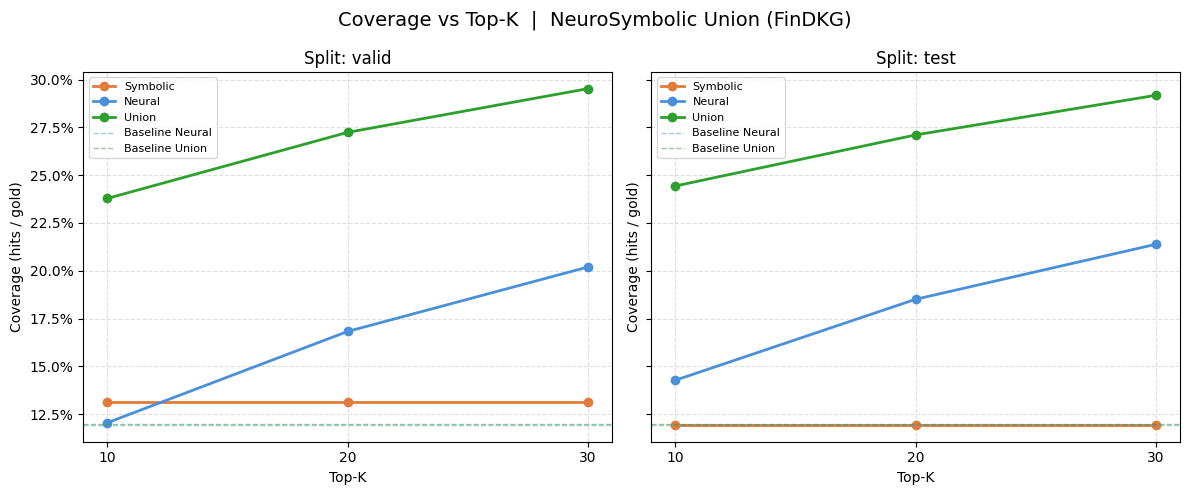

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle("Coverage vs Top-K  |  NeuroSymbolic Union (FinDKG)", fontsize=14)

colors = {"sym_coverage": "#E07B39", "neu_coverage": "#4A90D9", "union_coverage": "#2CA02C"}
labels = {"sym_coverage": "Symbolic", "neu_coverage": "Neural", "union_coverage": "Union"}
b = df_baseline.iloc[0]

for ax, split in zip(axes, ["valid", "test"]):
    df_split = df_main[df_main["split"] == split].sort_values("top_k")
    for col, color in colors.items():
        ax.plot(df_split["top_k"], df_split[col], marker="o",
                label=labels[col], color=color, linewidth=2)
    ax.axhline(b["neu_coverage"], linestyle="--", color="#4A90D9", alpha=0.5, linewidth=1, label="Baseline Neural")
    ax.axhline(b["union_coverage"], linestyle="--", color="#2CA02C", alpha=0.5, linewidth=1, label="Baseline Union")
    ax.set_title(f"Split: {split}")
    ax.set_xlabel("Top-K")
    ax.set_ylabel("Coverage (hits / gold)")
    ax.set_xticks([10, 20, 30])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "plots", "coverage_vs_topk.png"), dpi=150)
plt.show()

## Plot 2 — Coverage Grouped Bar Chart (test split)

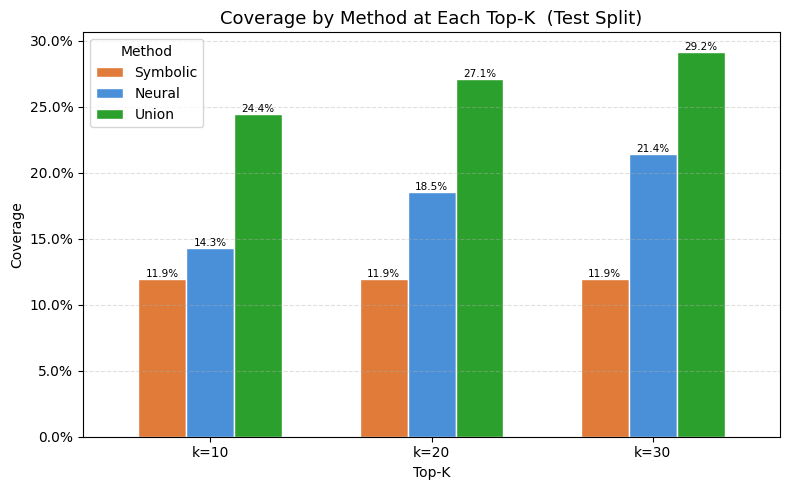

In [4]:
df_test = df_main[df_main["split"] == "test"].sort_values("top_k").set_index("top_k")
plot_df = df_test[["sym_coverage", "neu_coverage", "union_coverage"]].rename(
    columns={"sym_coverage": "Symbolic", "neu_coverage": "Neural", "union_coverage": "Union"}
)

ax = plot_df.plot(kind="bar", figsize=(8, 5),
                  color=["#E07B39", "#4A90D9", "#2CA02C"],
                  edgecolor="white", width=0.65)
ax.set_title("Coverage by Method at Each Top-K  (Test Split)", fontsize=13)
ax.set_xlabel("Top-K")
ax.set_ylabel("Coverage")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_xticklabels(["k=10", "k=20", "k=30"], rotation=0)
ax.legend(title="Method")
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar in ax.patches:
    ax.annotate(f"{bar.get_height():.1%}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "plots", "coverage_bars_test.png"), dpi=150)
plt.show()

## Plot 3 — Hit Counts Grouped Bar Chart (test split)

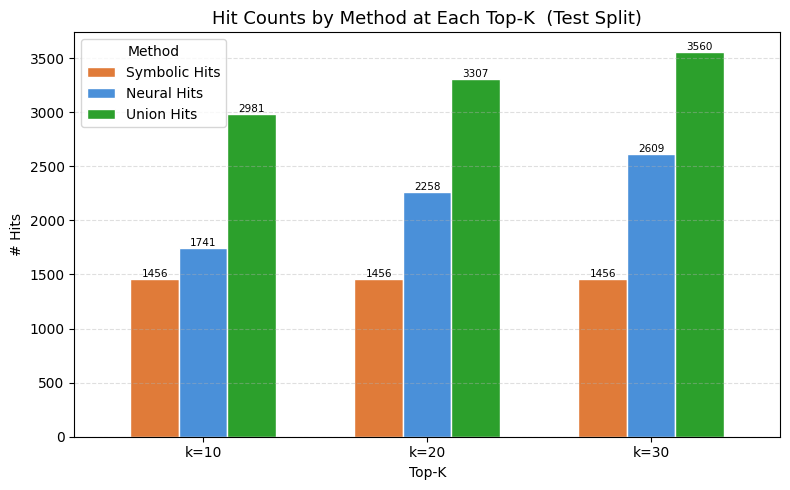

In [5]:
df_test = df_main[df_main["split"] == "test"].sort_values("top_k").set_index("top_k")
plot_df = df_test[["sym_hit", "neu_hit", "union_hit"]].rename(
    columns={"sym_hit": "Symbolic Hits", "neu_hit": "Neural Hits", "union_hit": "Union Hits"}
)

ax = plot_df.plot(kind="bar", figsize=(8, 5),
                  color=["#E07B39", "#4A90D9", "#2CA02C"],
                  edgecolor="white", width=0.65)
ax.set_title("Hit Counts by Method at Each Top-K  (Test Split)", fontsize=13)
ax.set_xlabel("Top-K")
ax.set_ylabel("# Hits")
ax.set_xticklabels(["k=10", "k=20", "k=30"], rotation=0)
ax.legend(title="Method")
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height())}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "plots", "hit_counts_test.png"), dpi=150)
plt.show()